In [2]:
using Pkg
Pkg.activate("/Users/jercheal/.julia/environments/v1.11/transfer_matrix_poly/")
using Plots
using NLsolve
using BenchmarkTools
#using Polylogarithms #removed due to conflict with LsqFit package
using LinearAlgebra
using CSV
using DataFrames
#using NonlinearSolve
#using LsqFit

include("wynn.jl")
include("transfer_matrix.jl")

  Activating project at `~/.julia/environments/v1.11/transfer_matrix_poly`


rel_Var (generic function with 1 method)

In [8]:
using LaTeXStrings
plot_font = "Computer Modern"
default(fontfamily=plot_font,
        linewidth=2, framestyle=:box, label=nothing, grid=false)
scalefontsizes(1.0)

In [26]:
function read_data(path::String)
    eval_pre = CSV.read(path, DataFrame)
    N = size(eval_pre)[1]
    M = length(split(eval_pre[1,1][2:end-1], ", "))
    eval = fill(zeros(Float64, M), N, N)
    for i in 1:N
        for j in i:N
            element = parse.(Float64, split(eval_pre[i,j][2:end-1], ", "))
            eval[i,j] = element
            eval[j,i] = element
        end
    end
    return eval
end

read_data (generic function with 1 method)

# Evaluating cluster data with $a_{\max} = 350$, $V = 14$ and the `trans_mat_v3` 

In [33]:
eval_j = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_j_v3.csv");
eval_k = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_k_v3.csv");

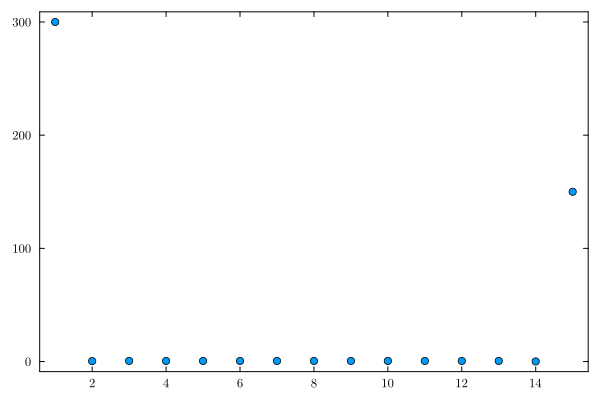

In [21]:
scatter(14^2 .* eval_j[300, 600])

In [36]:
eval_k[300, 600]

14-element Vector{Float64}:
  3.3859650892347974
  0.6047841435610802
  0.0842322416100924
  0.04402814127866558
  0.03899899061411034
  0.039690123273778896
  0.04014640321467218
  0.040043626575361875
  0.03941903556761581
  0.03975913976884891
  0.052073767122232696
  0.12120510608896383
 -0.1163678756541104
  4.782257246909896

In [43]:
js = solve_eom(150.0, 300.0, 0.1, 1.0, 14, 24.3)[1]

15-element Vector{Float64}:
 150.0
 158.99921458638863
 168.26171163731095
 177.78762493280163
 187.57709187330113
 197.6302534642381
 207.94725429774473
 218.52824255491888
 229.37336997133804
 240.48279184180782
 251.856666999364
 263.4951577927141
 275.39843007842046
 287.5666532056529
 300.0

In [49]:
150 * 2 * 3

900

# Evaluating cluster data with $a_{\max} = 150$, $V = 3$ and the `trans_mat_v3` 

In [50]:
eval_j = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_j_V3_max150.csv")

900×900 Matrix{Vector{Float64}}:
 [0.0185185, 0.0261487, 0.0261487, 0.0185185]  …  [0.0185185, 0.0372142, -0.0401254, 16.6667]
 [0.0185185, 0.029087, 0.0348918, 0.037037]       [0.037037, 0.0506011, -0.075662, 16.6667]
 [0.0185185, 0.0316398, 0.0428768, 0.0555556]     [0.0555556, 0.0620816, -0.107093, 16.6667]
 [0.0185185, 0.0338596, 0.0501988, 0.0740741]     [0.0740741, 0.0720329, -0.126813, 16.6667]
 [0.0185185, 0.0357925, 0.0569095, 0.0925926]     [0.0925926, 0.0804722, -0.118945, 16.6667]
 [0.0185185, 0.0375167, 0.063151, 0.111111]    …  [0.111111, 0.0872786, -0.0536062, 16.6667]
 [0.0185185, 0.0391058, 0.0691203, 0.12963]       [0.12963, 0.0917877, 0.115483, 16.6667]
 [0.0185185, 0.04054, 0.0747192, 0.148148]        [0.148148, 0.0931396, 0.438399, 16.6667]
 [0.0185185, 0.0418664, 0.0800626, 0.166667]      [0.166667, 0.090998, 0.895228, 16.6667]
 [0.0185185, 0.0431077, 0.0852091, 0.185185]      [0.185185, 0.0867851, 1.32602, 16.6667]
 ⋮                                             ⋱

In [56]:
eval_j_v2 = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_j_V3_max150_v2.csv")

900×900 Matrix{Vector{Float64}}:
 [0.0185185, 0.0185215, 0.0185215, 0.0185185]  …  [0.0185185, 4.25655, 11.626, 16.6667]
 [0.0185185, 0.0247121, 0.0308846, 0.037037]      [0.037037, 4.22335, 11.5481, 16.6667]
 [0.0185185, 0.0309238, 0.0432687, 0.0555556]     [0.0555556, 4.23602, 11.5462, 16.6667]
 [0.0185185, 0.0371474, 0.0556647, 0.0740741]     [0.0740741, 4.26234, 11.5565, 16.6667]
 [0.0185185, 0.0433726, 0.0680626, 0.0925926]     [0.0925926, 4.27671, 11.5538, 16.6667]
 [0.0185185, 0.0495958, 0.0804585, 0.111111]   …  [0.111111, 4.29029, 11.5584, 16.6667]
 [0.0185185, 0.0558269, 0.0928624, 0.12963]       [0.12963, 4.31543, 11.5691, 16.6667]
 [0.0185185, 0.0620523, 0.105261, 0.148148]       [0.148148, 4.32882, 11.5661, 16.6667]
 [0.0185185, 0.068276, 0.117658, 0.166667]        [0.166667, 4.34199, 11.5704, 16.6667]
 [0.0185185, 0.0745109, 0.130066, 0.185185]       [0.185185, 4.36675, 11.5808, 16.6667]
 ⋮                                             ⋱  
 [0.0185185, 4.20729, 11.4857, 16.

In [58]:
3^2 .* eval_j_v2[300, 600]

4-element Vector{Float64}:
  50.0
  66.0484440260347
  83.2033941332581
 100.0

In [71]:
solve_eom(5.0, 10.0, 0.1, 1.0, 3, 5.0)

([5.0, 6.475887771290133, 8.142427720185829, 10.0], [0.5624482129977465, 0.5627145789958361, 0.5630116395960709], [0.709617612447222, 0.629657375510395, 0.5662325417007242], [0.0, 0.709617612447222, 1.3392749879576171, 1.9055075296583412])

In [81]:
3 * 300 * 2

1800

In [76]:
3^2 .* eval_j_v2[30, 60]

4-element Vector{Float64}:
  5.0
  6.663914104168559
  8.331133196408922
 10.0

In [77]:
size(eval_j)

(900, 900)

# Evaluating cluster data with $a_{\max} = 300$, $V = 3$ and the `trans_mat_v2` 

In [19]:
V = 3
Λ = 0.1
γ = 1.0
α = 2.5
a_max = 300.0
N = Int(2 * a_max * V);

In [27]:
eval_j = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_j_V3_max300.csv");
eval_j_sq = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_j_sq_V3_max300.csv");
eval_k = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_k_V3_max300.csv");
eval_k_sq = read_data("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/eval_k_sq_V3_max300.csv");

Let's look at the deviation from semi-classical results when we scale up the boundary data.

In [39]:
rel_MSE_j = zeros(Float64, 15)
rel_MSE_k = zeros(Float64, 15)
for i in 1:15
    sols = solve_eom(10.0 * i, 20.0 * i, Λ, γ, V, 6.0 + i)
    j_sols = sols[1]
    k_sols = sols[2]
    rel_MSE_j[i] = sum((V^2 .* eval_j[Int(60*i),Int(120*i)] - j_sols).^2 ./ (j_sols .^ 2)) / 2
    rel_MSE_k[i] = sum((eval_k[Int(60*i),Int(120*i)] - k_sols).^2 ./ (k_sols .^ 2)) / 2
end

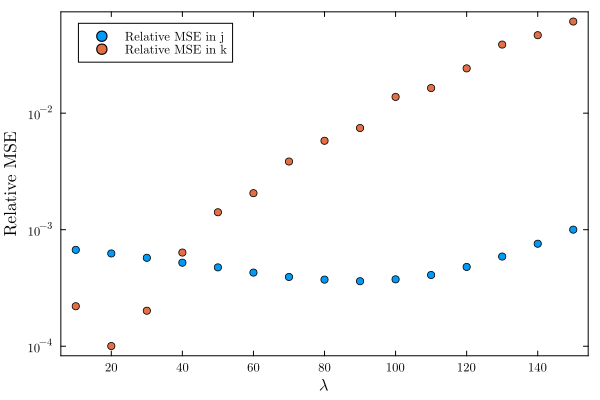

In [40]:
λs = [10.0 * i for i in 1:15]
scatter(λs, rel_MSE_j, label="Relative MSE in j", xlabel=L"\lambda", ylabel="Relative MSE")
scatter!(λs, rel_MSE_k, label="Relative MSE in k", yscale=:log10)

In [47]:
rel_Var_j = zeros(Float64, 15)
rel_Var_k = zeros(Float64, 15)
for i in 1:15
    rel_Var_j[i] = sum(sqrt.(abs.((V^4 .* eval_j_sq[Int(60*i),Int(120*i)] - (V^2 .* eval_j[Int(60*i), Int(120*i)]) .^ 2))) ./ (V^2 .* eval_j[Int(60*i), Int(120*i)])) / (V - 1)
    rel_Var_k[i] = sum(sqrt.(abs.(eval_k_sq[Int(60*i),Int(120*i)] - (eval_k[Int(60*i), Int(120*i)]) .^ 2)) ./ (eval_k[Int(60*i), Int(120*i)])) / V
end

In [57]:
deviations = DataFrame()
deviations.rel_MSE_j = rel_MSE_j
deviations.rel_MSE_k = rel_MSE_k
deviations.rel_Var_j = rel_Var_j
deviations.rel_Var_k = rel_Var_k
deviations

Row,rel_MSE_j,rel_MSE_k,rel_Var_j,rel_Var_k
,Float64,Float64,Float64,Float64
1,0.00067136,0.000220385,0.318222,1.37463
2,0.000625405,0.000100335,0.318448,1.39069
3,0.000573595,0.000201658,0.318581,1.38969
4,0.00052101,0.00063652,0.318635,1.38323
5,0.000474838,0.00141136,0.318588,1.40194
6,0.000428414,0.00205696,0.318482,1.3835
7,0.000393071,0.00384512,0.318268,1.38079
8,0.000372735,0.0057945,0.317924,1.42521
9,0.00036138,0.00745646,0.317515,1.41984


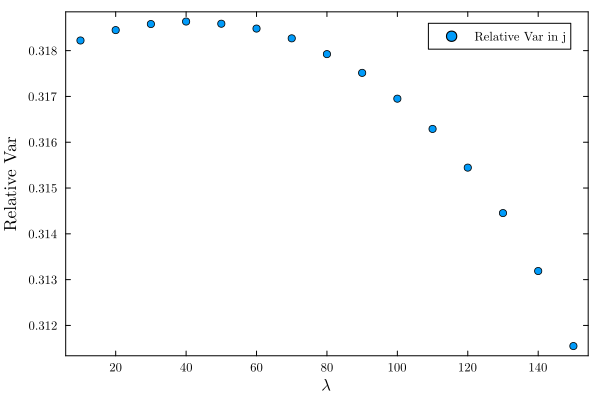

In [48]:
scatter(λs, rel_Var_j, label="Relative Var in j", xlabel=L"\lambda", ylabel="Relative Var")

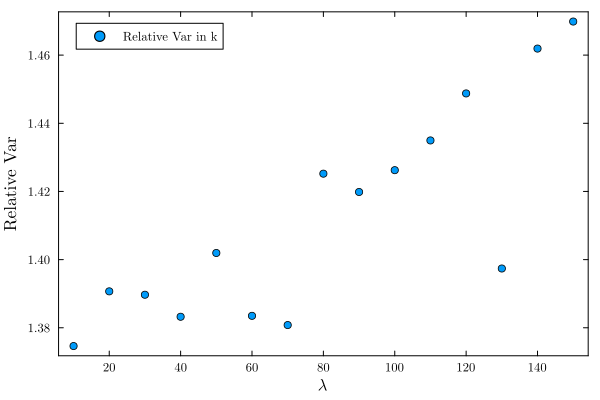

In [49]:
scatter(λs, rel_Var_k, label="Relative Var in k", xlabel=L"\lambda", ylabel="Relative Var")

As per usual, the expectation values of $k$ give rise to problems, showing significant fluctuations in the quantum sense and deviations from the classical solutions. Given that, let's see whether this arises from how we compute the expectation values. More precisely, the way we compute $Z[k_n]$ right now is
$$
Z[K_n] = T[1](j_0,j_n)\cdot T[k_n](j_n, j_{n+1})\cdot T[1](j_{n+1}, j_V),
$$
so by defining a matrix $T[k]$ with a $k$-insertion and then a contraction with the other variables. We can investigate whether this approach might be flawed by first performing all the contractions and only at the very end take the sum over $k_n$, so
$$
Z[K_n] = \sum_{k_n}T[1](j_0,j_n)\mathcal{A}(j_n, j_{n+1}, k_n)k_nT[1](j_{n+1},j_V), 
$$
with the contractions over bulk $j$ being performed first.\
\
To that end, let us first import the transfer matrix.

In [20]:
T = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/transf_mat_V3_max300.csv", DataFrame)
T = parse.(ComplexF64, Matrix(T));
Z = T^3;
T_sq = T^2;

In [21]:
j_range = 0.5/V^3:0.5/V^3:300.0
k_range = 0.5/V^3:0.5/V^3:50.0
k_sol_1 = solve_eom(50.0, 100.0, 0.1, 1.0, 3, 15.0)[2][1];

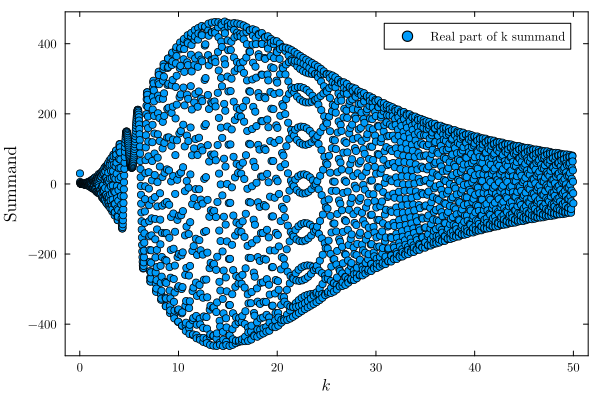

In [58]:
k_summand = [sum([ k * μ_toy(γ * 0.5 * 300 / V, γ * 0.5 * i / V, k, α) *  exp(V^3 * im * S_III(γ * 0.5 * 300 / V^3, γ * 0.5 * i / V^3, k, Λ)) * T_sq[i, 600] for i in 1:N]) for k in k_range];
k_sq_summand = [sum([ k^2 * μ_toy(γ * 0.5 * 300 / V, γ * 0.5 * i / V, k, α) *  exp(V^3 * im * S_III(γ * 0.5 * 300 / V^3, γ * 0.5 * i / V^3, k, Λ)) * T_sq[i, 600] for i in 1:N]) for k in k_range];
scatter(k_range, real.(k_summand), label="Real part of k summand", xlabel=L"k", ylabel="Summand")
#scatter!(k_range, real.(accumulate(+, k_summand)))

In [59]:
wynn(accumulate(+, k_summand)[end-50:end], 1e-10)[1] / Z[300, 600]

1.6831347891278987 - 0.5610439969795261im

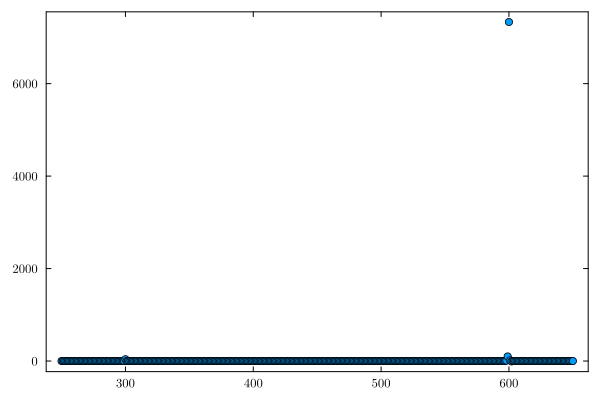

In [24]:
j1_summand = [wynn(accumulate(+, [ k * μ_toy(γ * 0.5 * 300 / V, γ * 0.5 * i / V, k, α) *  exp(V^3 * im * S_III(γ * 0.5 * 300 / V^3, γ * 0.5 * i / V^3, k, Λ)) for k in k_range])[end-50:end], 1e-10)[1] * T_sq[i, 600] for i in 1:N]
scatter(250:650, real.(j1_summand)[250:650])

In [27]:
j1_summand[595:605]

11-element Vector{ComplexF64}:
  0.3168173665574868 + 0.06621922746733368im
  0.7452111391203762 + 0.13399297945620986im
  2.2061719843264873 + 0.4486425524597503im
   9.652455667177273 + 2.710168165243279im
   98.94328370969615 + 50.2135492545109im
   7333.682309076729 + 4261.487931963675im
  15.102035116757925 - 108.0245666230137im
  -8.878550048850208 + 3.6168194185936406im
  1.4945200953250208 + 1.4764544540447555im
 0.28445147559205963 - 0.634415420553166im
 -0.2887290711631127 - 0.033146104489016996im

In [62]:
sum(j1_summand) / Z[300, 600]

1.6831351841293092 - 0.5610430835271241im

In [28]:
sum(j1_summand)

7494.686550932437 + 4265.544798241225im

In [31]:
(sum(j1_summand[295:305]) + sum(j1_summand[595:605])) / Z[300, 600]

1.6830161335489735 - 0.5609892713679848im

Observations:

1. The summations do commute very nicely. This is a result of the absolute convergence of the summands due to our choice of measure.
2. The summand is highly peaked on $j_0$ and $j_V$ such that the final sum can be approximated by a local summation around these two points. Is this the problem for the strong variations in $k$? because if $T(j,j)$ are dominant, these are the configurations where there is no classical solution for $k$.

Next, I want to inspect whether the deviations in the $k$ summations can be improved by refining the spectrum of the single $k$-summation. Recall that the solution to the equations of motion is given by $k_0 = 1.7712364825186788$.

In [112]:
ref_tl = 1.0
k_range_ref = ref_tl * 0.5 / V^3 : ref_tl * 0.5 / V^3 : 60.0
k_summand_ref = [sum([ k * μ_toy(γ * 0.5 * 900 / V, γ * 0.5 * i / V, k, α) *  exp(V^3 * im * S_III(γ * 0.5 * 900 / V^3, γ * 0.5 * i / V^3, k, Λ)) * T_sq[i, 1800] for i in 1:N]) for k in k_range_ref];
k_sq_summand_ref = [sum([ k^2 * μ_toy(γ * 0.5 * 900 / V, γ * 0.5 * i / V, k, α) *  exp(V^3 * im * S_III(γ * 0.5 * 900 / V^3, γ * 0.5 * i / V^3, k, Λ)) * T_sq[i, 1800] for i in 1:N]) for k in k_range_ref];

In [114]:
wynn(accumulate(+, k_summand_ref)[end-50:end], 1e-10)[1] / Z[900, 1800]

2.2381606999141503 - 2.7215629610105476im

In [95]:
solve_eom(150.0, 300.0, 0.1, 1.0, 3, 24.3)[2][1]

3.0423448714529626

Refining doesn't help!

In [32]:
deviations_V3 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V3_max300.csv", DataFrame)
deviations_V3 = Matrix(deviations_V3)
deviations_V4 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V4_max300.csv", DataFrame)
deviations_V4 = Matrix(deviations_V4)
deviations_V5 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V5_max300.csv", DataFrame)
deviations_V5 = Matrix(deviations_V5)
deviations_V6 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V6_max300.csv", DataFrame)
deviations_V6 = Matrix(deviations_V6);
deviations_V7 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V7_max300.csv", DataFrame)
deviations_V7 = Matrix(deviations_V7);
deviations_V8 = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V8_max300.csv", DataFrame)
deviations_V8 = Matrix(deviations_V8);

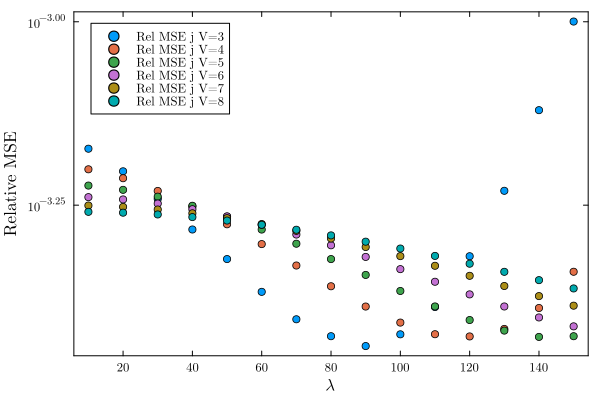

In [33]:
λs = [10.0 * i for i in 1:15]
scatter(λs, deviations_V3[:,1], label="Rel MSE j V=3", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
scatter!(λs, deviations_V4[:,1], label="Rel MSE j V=4")
scatter!(λs, deviations_V5[:,1], label="Rel MSE j V=5")
scatter!(λs, deviations_V6[:,1], label="Rel MSE j V=6")
scatter!(λs, deviations_V7[:,1], label="Rel MSE j V=7")
scatter!(λs, deviations_V8[:,1], label="Rel MSE j V=8")

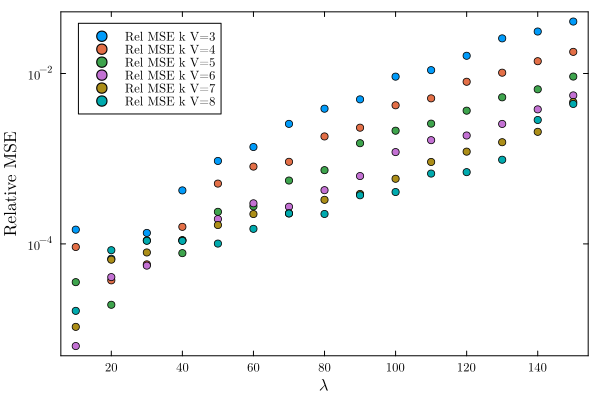

In [34]:
scatter(λs, deviations_V3[:,2], label="Rel MSE k V=3", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
scatter!(λs, deviations_V4[:,2], label="Rel MSE k V=4")
scatter!(λs, deviations_V5[:,2], label="Rel MSE k V=5")
scatter!(λs, deviations_V6[:,2], label="Rel MSE k V=6")
scatter!(λs, deviations_V7[:,2], label="Rel MSE k V=7")
scatter!(λs, deviations_V8[:,2], label="Rel MSE k V=8")

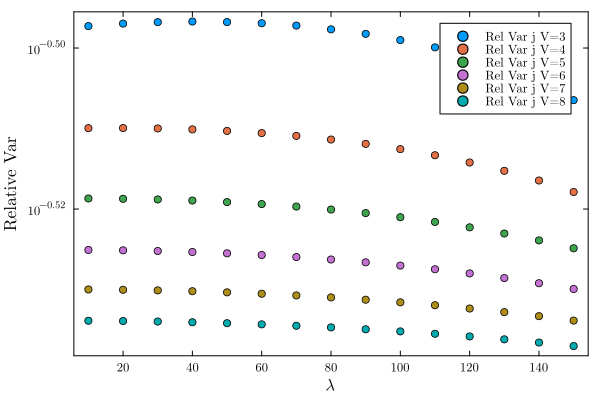

In [35]:
scatter(λs, deviations_V3[:,3], label="Rel Var j V=3", xlabel=L"\lambda", ylabel="Relative Var", yscale=:log10)
scatter!(λs, deviations_V4[:,3], label="Rel Var j V=4")
scatter!(λs, deviations_V5[:,3], label="Rel Var j V=5")
scatter!(λs, deviations_V6[:,3], label="Rel Var j V=6")
scatter!(λs, deviations_V7[:,3], label="Rel Var j V=7")
scatter!(λs, deviations_V8[:,3], label="Rel Var j V=8")

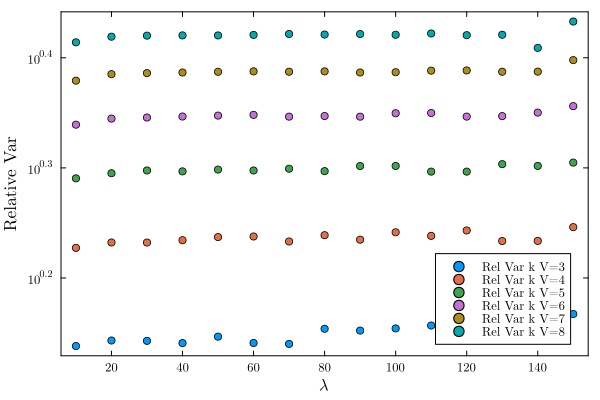

In [36]:
scatter(λs, deviations_V3[:,4], label="Rel Var k V=3", xlabel=L"\lambda", ylabel="Relative Var", yscale=:log10)
scatter!(λs, deviations_V4[:,4], label="Rel Var k V=4")
scatter!(λs, deviations_V5[:,4], label="Rel Var k V=5")
scatter!(λs, deviations_V6[:,4], label="Rel Var k V=6")
scatter!(λs, deviations_V7[:,4], label="Rel Var k V=7")
scatter!(λs, deviations_V8[:,4], label="Rel Var k V=8")

In [40]:
refs = ["_ref06", "_ref07", "_ref08", "_ref09", ""]
deviations = []
for ref in refs
    dev = CSV.read("/Users/jercheal/Documents/Physics/Projects/transfer_matrix/data/deviations_V3_max300$ref.csv", DataFrame)
    dev = Matrix(dev)
    push!(deviations, dev)
end


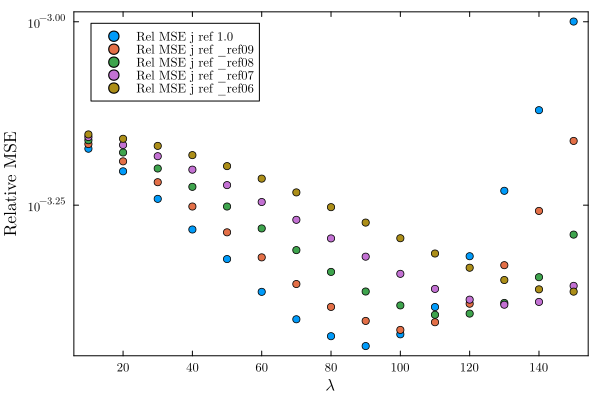

In [49]:
λs = [10.0 * i for i in 1:15]
plt = scatter(λs, deviations[5][:,1], label="Rel MSE j ref 1.0", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
for i in 4:-1:1
    ref = refs[i]
    scatter!(λs, deviations[i][:,1], label="Rel MSE j ref $ref", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
end
display(plt)

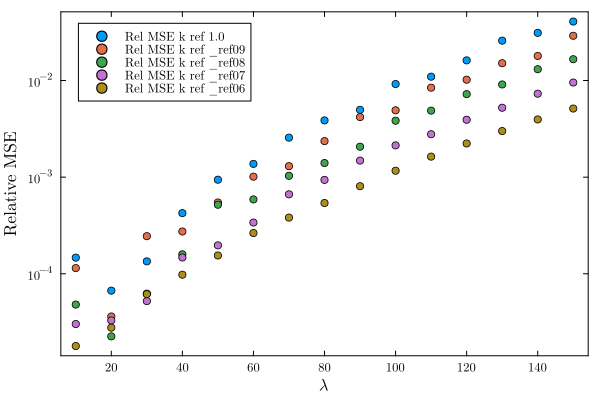

In [48]:
plt = scatter(λs, deviations[5][:,2], label="Rel MSE k ref 1.0", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
for i in 4:-1:1
    ref = refs[i]
    scatter!(λs, deviations[i][:,2], label="Rel MSE k ref $ref", xlabel=L"\lambda", ylabel="Relative MSE", yscale=:log10)
end
display(plt)

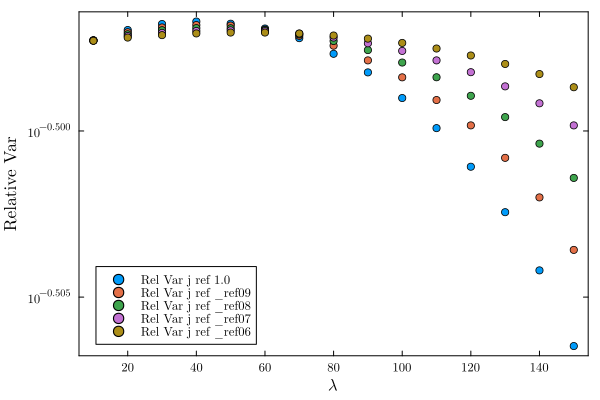

In [51]:
plt = scatter(λs, deviations[5][:,3], label="Rel Var j ref 1.0", xlabel=L"\lambda", ylabel="Relative Var", yscale=:log10)
for i in 4:-1:1
    ref = refs[i]
    scatter!(λs, deviations[i][:,3], label="Rel Var j ref $ref", xlabel=L"\lambda", ylabel="Relative Var", yscale=:log10)
end
display(plt)

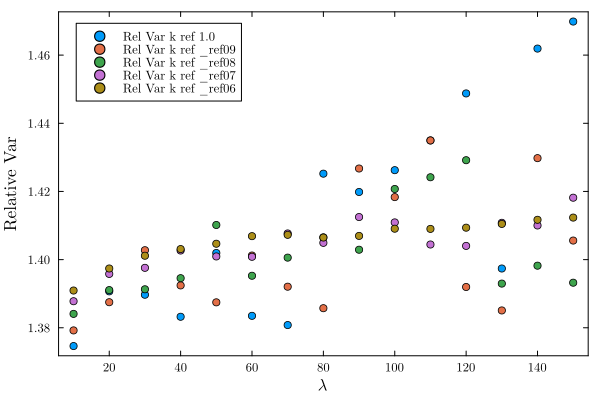

In [53]:
plt = scatter(λs, deviations[5][:,4], label="Rel Var k ref 1.0", xlabel=L"\lambda", ylabel="Relative Var")
for i in 4:-1:1
    ref = refs[i]
    scatter!(λs, deviations[i][:,4], label="Rel Var k ref $ref", xlabel=L"\lambda", ylabel="Relative Var")
end
display(plt)